In [1]:
%matplotlib widget
# Boilerplate import code for all libraries
# Changes to the precision require re-loading the kernel and need to be done before any op uses them.
import warpSPHCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double

import warpSPHCore as sph
from warpSPHCore.type_config import *
print(get_type_config()) # confirms active settings

# Initialize warp at this point
import warp as wp; wp.init()

import os
import torch
if torch.cuda.is_available(): # set the TORCH_CUDA_ARCH_LIST environment variable to the compute capability of the GPU for faster compiles
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

# final import blocks that are generic
import matplotlib.pyplot as plt
from torch.profiler import profile, record_function, ProfilerActivity
import numpy as np
import math
import shlex    
import subprocess
import shutil

# custom SPH libraries
from warpSPHIntegrators.integration import *
from warpSPHCore import *
from warpSPHPlotting import *

# This library
from warpSPH import *

# The case utilities that contain all the case setup functions for the various test cases
from warpSPH.caseUtils import *

{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}
Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:

R = 1
L = 2 *3 * R
nx = 192
dx = L / nx
targetDt = 0.0005
rho0 = 1
freeSurface = True
band = 0
fps = 50
timeLimit = 1

dim = 2
n_h = 4


extraData = {
    'nx': nx,
    'dim': dim,
    'L': L,
    'n_h': n_h,

    'rho0': rho0,

    'R': R,
    
}

In [3]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()



dx = L / (nx)
band = 0

domain = buildDomainDescription(L + dx * (band) * 2, dim, True, device, dtype)
interiorDomain = buildDomainDescription(L, dim, False, device, dtype)

config, integrator = buildConfig(
    domain = domain,
    dim = dim,
    kernel = KernelFunctions.Wendland4,
    targetNeighbors = n_h_to_nH(4, dim),
    supportMode = SupportScheme.KernelMeanSymmetric,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = None,
    adaptiveDt = True,
    cflFactor=0.3,
)
config.nx = nx + band * 2
config.dx = (interiorDomain.max[0] - interiorDomain.min[0]) / (nx)

config.minDt = 1e-8
# config.dx = L / (nx * 2)

scheme = IncompressibleSPHScheme.divergenceFree
SimulationSystem, SimulationState, SimulationConfig, SimulationUpdate, fn, export_fn, import_fn = buildScheme(scheme)


schemeConfig = SimulationConfig()
schemeConfig.surfaceDetectionConfig.active = freeSurface

In [4]:
schemeConfig.gravityConfig.active = False

In [5]:
H = 1

fluid_a = lambda points: sampleSDF(points, operatorDict['translate'](lambda x: getSDF('box')['function'](x, torch.tensor([H,H]).to(points.device)), torch.tensor([0,0]).to(points.device)), invert = False)

regions = []

regions.append(buildRegion(config, schemeConfig, fluid_a, RegionType.Fluid, initialConditions = {}))

for region in regions:
    region = filterRegion(region, regions)


for region in regions:
    region = filterRegion(region, regions)


In [6]:
fluid_a = lambda points: sampleSDF(points, operatorDict['translate'](lambda x: getSDF('circle')['function'](x, torch.tensor(1/2).to(points.device)), torch.tensor([-0.75,0.]).to(points.device)), invert = False)
fluid_b = lambda points: sampleSDF(points, operatorDict['translate'](lambda x: getSDF('circle')['function'](x, torch.tensor(1/2).to(points.device)), torch.tensor([0.75,0.]).to(points.device)), invert = False)

regions = []

regions.append(buildRegion(sdf = fluid_a, config = config, schemeConfig = schemeConfig, regionType = RegionType.Fluid))
regions.append(buildRegion(sdf = fluid_b, config = config, schemeConfig = schemeConfig, regionType = RegionType.Fluid))
for region in regions:
    region = filterRegion(region, regions)


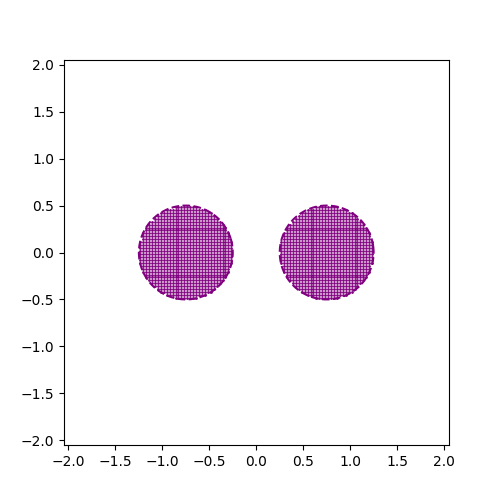

In [7]:
fig, axis = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)
    
plotRegions(regions, axis[0,0], plotFluid = True, plotParticles = True)

rectangle = plt.Rectangle((domain.min[0].cpu().numpy(), domain.min[1].cpu().numpy()), domain.max[0].cpu().numpy() - domain.min[0].cpu().numpy(), domain.max[1].cpu().numpy() - domain.min[1].cpu().numpy(), fill=False, color='black', lw=2)
axis[0,0].add_patch(rectangle)

rectangleInterior = plt.Rectangle((interiorDomain.min[0].cpu().numpy(), interiorDomain.min[1].cpu().numpy()), interiorDomain.max[0].cpu().numpy() - interiorDomain.min[0].cpu().numpy(), interiorDomain.max[1].cpu().numpy() - interiorDomain.min[1].cpu().numpy(), fill=False, color='red', lw=2)
axis[0,0].add_patch(rectangleInterior)

import matplotlib.patches as patches

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(domain.min[0].item(), domain.max[0].item())
    ax.set_ylim(domain.min[1].item(), domain.max[1].item())

for ax in axis.flatten():
    ax.set_xlim(-2.05*R, 2.05*R)
    ax.set_ylim(-2.05*R, 2.05*R)

In [8]:
compressibleSystem = initializeWeaklyCompressibleSimulation(regions, config, schemeConfig, SimulationSystem, SimulationState, verbose = True)

omega = 4

compressibleSystem.state.velocities[:,0] = omega * compressibleSystem.state.positions[:,1]
compressibleSystem.state.velocities[:,1] = -omega * compressibleSystem.state.positions[:,0]

schemeConfig.fluid.fixedSoundSpeed, config.dt = setupWeaklyCompressibleTimestep(config, schemeConfig, compressibleSystem, targetDt, verbose = True)

densities = computeDensities(compressibleSystem.state, config, schemeConfig, None)
print(f"Initial density stats: mean: {densities.mean().cpu().item():.6g}, min: {densities.min().cpu().item():.6g}, max: {densities.max().cpu().item():.6g}")
compressibleSystem.state.masses = compressibleSystem.state.masses / densities.max() * rho0
densities = computeDensities(compressibleSystem.state, config, schemeConfig, None)
print(f"After correction density stats: mean: {densities.mean().cpu().item():.6g}, min: {densities.min().cpu().item():.6g}, max: {densities.max().cpu().item():.6g}")


Computed c0: 34.54248809814453, target c0: 10.0, diff: 24.54248809814453
Computed dt: 0.0005000000237487257, target dt: 0.0005, diff: 0.0
Max velocity: 4.956844806671143, CFL: 0.07930952310562134, Max Mach: 0.1434999406337738
Module warpSPHCore.radiusSearch.wp_compactHash 55d44f3 load on device 'cuda:0' took 2.76 ms  (cached)
Module warpSPHCore.operations_grid.wp_density_grid 3761b33 load on device 'cuda:0' took 3.15 ms  (cached)
Initial density stats: mean: 0.956353, min: 0.58973, max: 1.00042
After correction density stats: mean: 0.955955, min: 0.589485, max: 1


In [9]:
runningState = compressibleSystem.initializeNewState()

caseName = 'squarePatch'
exportPath = prepExport(f'{caseName}', config, schemeConfig, scheme, export_fn)
# exportSimulationSystem(exportPath, 'initialState', scheme, compressibleSystem, exportAdjacency = False, stages = None, exportStagesAdjacency = False, extraData = dict({
#     'frame_num': 0,
# }, **extraData))

In [10]:
config.dt = 1e-3
schemeConfig.solverConfig.pressureSolver.tolerance = 1e-4
runningState = compressibleSystem.initializeNewState()
# runningState.state.positions = shuffleParticles(runningState.state, config, schemeConfig, 0, jitterAmount = 0.01)
runningState.state.velocities = torch.zeros_like(runningState.state.velocities, device=config.device, dtype=config.dtype)
runningState.state.pressures = torch.zeros_like(runningState.state.densities, device=config.device, dtype=config.dtype)
adjacency = None

trajectories = []
adjacency = buildVerletList(
    runningState.state, 
    config.domain, verletScale = 1.4, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = adjacency,
    verbose = False)
rhoInit = computeDensities(runningState.state, config, schemeConfig, adjacency)

for i in tqdm(range(1)):

    config.kernel = KernelFunctions.Wendland6
    adjacency = buildVerletList(
        runningState.state, 
        config.domain, verletScale = 1.0, supportMode = SupportScheme.SuperSymmetric,
        priorNeighborhood = adjacency,
        verbose = False)
    runningState.state.densities = computeDensities(runningState.state, config, schemeConfig, adjacency)
    runningState.state.pressures[:] = 0.0

    # config.kernel = KernelFunctions.Wendland6
    a_p, pressureB, errors, pressures = solveIncompressible(
            particles = runningState.state,
            config = config,
            schemeConfig = schemeConfig,
            adjacency = adjacency,
            dvdt = torch.zeros_like(runningState.state.velocities, device=config.device, dtype=config.dtype),
            dt = config.dt,
            verbose = True,
    )
    trajectories.append((errors,pressures))
 
    dx = config.dt**2 * a_p# * 0.01
    print(f'Iterations: {len(errors)}, Incompressible Error: {errors[0]:.4g}->{errors[-1]:.4g}')
    print(f"Position update: mean: {dx.mean().cpu().item():.6g}, min: {dx.min().cpu().item():.6g}, max: {dx.max().cpu().item():.6g}")

    # runningState.state.velocities = runningState.state.velocities + config.dt * a_p
    runningState.state.positions = runningState.state.positions + config.dt * config.dt * a_p #runningState.state.velocities

    if torch.any(torch.isnan(runningState.state.positions)):
        print(f"NaN detected in positions at iteration {i}. Stopping simulation.")
        break


Module warpSPHCore.operations.wp_density 681e434 load on device 'cuda:0' took 2.35 ms  (cached)


  0%|          | 0/1 [00:00<?, ?it/s]

Module warpSPHCore.operations.wp_divergence a5da11f load on device 'cuda:0' took 4.66 ms  (cached)
Incompressible Solver
[IS] Source term: 0.0171273, min: 0.000164568, max: 0.1 abs mean: 0.0171273
[IS] Mean density error: 0.0390567
Module warpSPH.modules.incompressible.wp_alpha e06ee3c load on device 'cuda:0' took 6.06 ms  (cached)
Module warpSPHCore.operations.wp_gradient 77e4101 load on device 'cuda:0' took 3.24 ms  (cached)
[IS] Iteration 1/64, error: -0.0001, pressure min/max/mean: (0.0, 0.0, 0.0)
[IS] Iteration 2/64, error: -0.0001, pressure min/max/mean: (0.0, 0.0, 0.0)
[IS] final Residual: 0.0171273, min: 0.000164568, max: 0.1
Iterations: 3, Incompressible Error: -0.0001->-0.0001
Position update: mean: 0, min: -0, max: -0


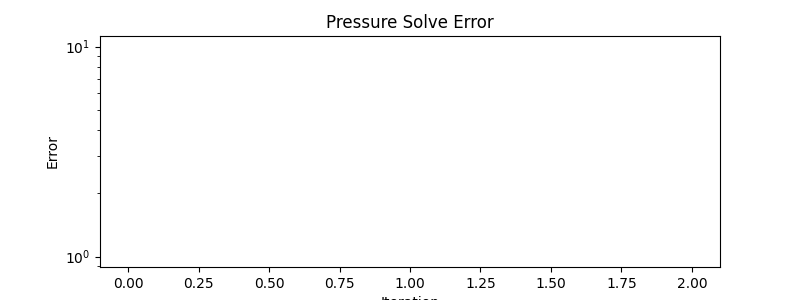

In [11]:
fig, axis = plt.subplots(1, 1, figsize=(8, 3), squeeze=False)

for i, (errors, pressures) in enumerate(trajectories):
    axis[0,0].plot(errors, label=f"Trajectory {i+1}")
axis[0,0].set_title("Pressure Solve Error")
axis[0,0].set_xlabel("Iteration")
axis[0,0].set_ylabel("Error")
axis[0,0].set_yscale('log')

In [12]:

markerSize = 8
plotter = visualize(
    particleState = compressibleSystem.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.densities,
        "B": runningState.state.pressures,
        "C": runningState.state.velocities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            # colorMap = DivergingColorMap.RdBu,
            # flipColorMap=True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            boundaryVisualization = VisualizeOptions.Visualize,
            # mapping = Mapping.x,
            plotTitle = "densities",
            # gridVisualization = GridVisualization(
            #     resolution = 1024,
            # ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = UniformColorMap.cividis,
            # colorMap = DivergingColorMap.RdBu,
            # flipColorMap=True,
            markerSize = markerSize,
            midPoint = 1.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "pressures",
            # mapping = Mapping.y,
            boundaryVisualization = VisualizeOptions.Hide,
            # vMin = 0.99,
            # vMax = 1.01
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
        "C": PlottingOptions(
            colorMap = UniformColorMap.mako,
            # colorMap = DivergingColorMap.RdBu,
            # flipColorMap=True,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "velocities",
            mapping = Mapping.L2Norm,
            boundaryVisualization = VisualizeOptions.Hide,
            # vMin=1e-10
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'ABC',
    figsize= (16,5),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)

imagePath = f'{exportPath}/images'
os.makedirs(imagePath, exist_ok = True)
plotter.export(f'{imagePath}/frame_00000.png', dpi  = 300)


RFBOutputContext()

In [13]:
runningState = compressibleSystem.initializeNewState()

runningState.state.velocities[:,0] = omega * runningState.state.positions[:,1]
runningState.state.velocities[:,1] = -omega * runningState.state.positions[:,0]
runningState.state.velocities[:,0] = 0.0
runningState.state.velocities[:,1] = 0.0
runningState.state.velocities[compressibleSystem.state.positions[:,0] < 0, 0] = 0.5
runningState.state.velocities[compressibleSystem.state.positions[:,0] > 0, 0] = -0.5


hMin = compressibleSystem.state.supports.min().cpu().item()
vMax = torch.linalg.norm(compressibleSystem.state.velocities, dim = -1).max().cpu().item()
velocityRatio = hMin / vMax
cflNumber = config.dt / velocityRatio


print(f"Initial hMin: {hMin:.6g}, vMax: {vMax:.6g}, CFL number: {cflNumber:.6g}")


Initial hMin: 0.125, vMax: 4.95684, CFL number: 0.0396548


In [15]:
# schemeConfig.solverConfig.pressureSolver.maxIterations = 32
# schemeConfig.solverConfig.pressureSolver.tolerance = 1e-4
# schemeConfig.solverConfig.divergenceFreeSolver.maxIterations = 2
schemeConfig.shiftProperties.active = False
schemeConfig.solverConfig
# schemeConfig.surfaceDetectionConfig.active = True

IncompressibleSolverConfig(pressureSolver=RelaxedJacobiSolverConfig(minIterations=2, maxIterations=64, tolerance=0.0001, relaxationFactor=0.3, antiCheckerboardFactor=0.05, antiCheckerboardThreshold=0.35, antiCheckerboardResidualGate=1.5), divergenceFreeSolver=RelaxedJacobiSolverConfig(minIterations=2, maxIterations=32, tolerance=0.0025, relaxationFactor=0.3, antiCheckerboardFactor=0.05, antiCheckerboardThreshold=0.35, antiCheckerboardResidualGate=1.5), integrateRho=False)

In [16]:
nSteps = int(timeLimit / config.dt)

# runningState = compressibleSystem.initializeNewState()
# nSteps = 1500
kes = []
priorStep = None
for i in (tq := tqdm(range(nSteps), leave = False)):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = fn,
        dt = config.dt,  
        config = config,
        schemeConfig = schemeConfig,
        verbose = False,
        # priorStep = priorStep
    )
    kes.append(torch.sum(0.5 * result.state.state.masses * torch.sum(result.state.state.velocities**2, dim=1)))
    # print('max_vel:', torch.linalg.norm(result.state.state.velocities, dim = -1).max())
    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)

    runningState = result.state

    if (i % 5 == 0 and i > 0) or (i == nSteps - 1):
        errors, pressures = result.stages[-1].aux[-2]
        numIters = len(errors)
        errors_incomp, pressures_incomp = result.stages[-1].aux[-1]
        numIters_incomp = len(errors_incomp)
        plotter.updateQuantities(
            {
                "A": runningState.state.densities,
                "B": runningState.state.pressures,
                "C": runningState.state.velocities,
            },
            newParticleState = runningState.state,
        )
        plotter.export(f'{imagePath}/frame_{i:05d}.png', dpi = 300)
        plotter.updateTitle(f'(Incompressible), t={(i+1)*config.dt:.3f}s ptcls={runningState.state.positions.shape[0]}, dt={config.dt:.3g}s\nDivergence Free error={errors[0]:.4g}->{errors[-1]:.4g} after {numIters} iterations, Incompressible error={errors_incomp[0]:.4g}->{errors_incomp[-1]:.4g} after {numIters_incomp} iterations')
        
    maxVel = torch.linalg.norm(runningState.state.velocities, dim = -1).max()
    tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{timeLimit:8.4g} | max vel: {maxVel:.3g} | iter time: {timing:.3f} ms")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break
    if torch.any(torch.isnan(runningState.state.velocities)):
        print("NaN detected in velocities, stopping simulation.")
        break

    div = computeMomentumIncompressible(
        currentState=runningState.state,
        config=config,
        schemeConfig=schemeConfig,
        adjacency=None,
        advectionVelocities=runningState.state.velocities
    )
    print(f"divergence stats: mean: {div.mean().cpu().item():.6g}, min: {div.min().cpu().item():.6g}, max: {div.max().cpu().item():.6g}")


  0%|          | 0/1000 [00:00<?, ?it/s]

Module warpSPHCore.renorm.wp_covariance e7bad65 load on device 'cuda:0' took 4.57 ms  (cached)
Module warpSPH.modules.surfaceDetection.wp_barecasco d6e01b1 load on device 'cuda:0' took 8.85 ms  (cached)
Module warpSPH.modules.surfaceDetection.wp_dilate c2ec31a load on device 'cuda:0' took 3.19 ms  (cached)
Module warpSPH.modules.deltaSPH.wp_viscosityDelta b587ee0 load on device 'cuda:0' took 3.53 ms  (cached)
Finalizing state at t=0.002, dt=0.001, with 1624 particles.
Solver Iterations: 3, Incompressible Error: -0.0001->-0.0001
Module warpSPHCore.operations.wp_gradient 6783d82 load on device 'cuda:0' took 6.29 ms  (cached)
Module warpSPHCore.operations_grid.wp_divergence_grid 9ab90cb load on device 'cuda:0' took 4.92 ms  (cached)
divergence stats: mean: 0, min: -0, max: -0
Finalizing state at t=0.003, dt=0.001, with 1624 particles.
Solver Iterations: 3, Incompressible Error: -0.0001->-0.0001
divergence stats: mean: 0, min: -0, max: -0
Finalizing state at t=0.004, dt=0.001, with 1624 pa

In [ ]:
currentState = runningState.state


adjacency = buildVerletList(
    currentState, 
    config.domain, verletScale = config.verletScale, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = None,
    verbose = False)
divergence = computeMomentumIncompressible(
        currentState = currentState, 
        config = config, 
        schemeConfig = schemeConfig, 
        adjacency = adjacency, 
        advectionVelocities = torch.zeros_like(currentState.velocities),
)
print("Divergence:", divergence.min(), divergence.max(), divergence.mean(), divergence.std())

Divergence: tensor(-0., device='cuda:0') tensor(-0., device='cuda:0') tensor(0., device='cuda:0') tensor(0., device='cuda:0')


In [ ]:
currentState.pressures

tensor([-17.7318, -60.2101, -52.9693,  ..., -52.9694, -60.2101, -17.7318],
       device='cuda:0')

In [ ]:
solveDivergenceFree(
        particles = currentState, 
        config = config, 
        schemeConfig = schemeConfig, 
        adjacency = adjacency, 
        dvdt = torch.zeros_like(currentState.velocities),
        dt = config.dt,
        verbose = True
)

Divergence Free Solver
[DF] Source term: 0, min: 0, max: 0
[DF] Iteration 1/32, residual min: -0.34643, max: 0.395912, mean: -0.0107699, error: 0.0534602, pressure min/max/mean: (-142.14772033691406, 214.5054168701172, -4.76837158203125e-07)
[DF] Iteration 2/32, residual min: -0.338118, max: 0.386383, mean: -0.0102811, error: 0.051643, pressure min/max/mean: (-140.79071044921875, 213.24830627441406, -5.960464477539063e-08)
[DF] Iteration 3/32, residual min: -0.329777, max: 0.377288, mean: -0.00982851, error: 0.0499184, pressure min/max/mean: (-139.44482421875, 212.02120971679688, 1.4901161193847656e-07)
[DF] Iteration 4/32, residual min: -0.321474, max: 0.368601, mean: -0.00940865, error: 0.0482797, pressure min/max/mean: (-138.11068725585938, 210.82273864746094, -2.9802322387695312e-08)
[DF] Iteration 5/32, residual min: -0.313269, max: 0.360287, mean: -0.00901833, error: 0.0467177, pressure min/max/mean: (-136.78878784179688, 209.6516571044922, 4.76837158203125e-07)
[DF] Iteration 6/

(tensor([[  8.4679,   8.4675],
         [ 15.5464,  30.1216],
         [ 69.2686,  -4.2279],
         ...,
         [-69.2685,   4.2276],
         [-15.5468, -30.1213],
         [ -8.4678,  -8.4676]], device='cuda:0'),
 tensor([-12.0595, -35.1631, -29.9185,  ..., -29.9185, -35.1630, -12.0595],
        device='cuda:0'),
 [0.053460195660591125,
  0.051642999053001404,
  0.04991839826107025,
  0.04827968403697014,
  0.04671771079301834,
  0.045272380113601685,
  0.04397401958703995,
  0.042758241295814514,
  0.04161293804645538,
  0.04052509367465973,
  0.039498843252658844,
  0.03850654512643814,
  0.03754551708698273,
  0.03661474213004112,
  0.035723231732845306,
  0.03486594185233116,
  0.034040968865156174,
  0.033246561884880066,
  0.03247644752264023,
  0.031735241413116455,
  0.031053656712174416,
  0.03042656183242798,
  0.029848862439393997,
  0.029295895248651505,
  0.02875763550400734,
  0.028238026425242424,
  0.027733873575925827,
  0.027241742238402367,
  0.0267679318785667

In [ ]:
exportSimulationSystem(exportPath, f'finalState', scheme, runningState, exportAdjacency = False, stages = result.stages, exportStagesAdjacency = True, extraData = dict(**extraData, **{
    'frame_num': i,
}))

In [18]:
ffmpeg_cmd = "ffmpeg -y -loglevel error -hide_banner -framerate 120 -f image2 -pattern_type glob -i 'frame_*.png' -c:v libx264 -pix_fmt yuv420p -b:v 10M output.mp4"
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4  -vf "fps=50,scale=540:-1:flags=lanczos,palettegen" palette.png'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4 -i palette.png -filter_complex "fps=25,scale=540:-1:flags=lanczos[x];[x][1:v]paletteuse" out.gif'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)

# now copy the output.mp4 and out.gif to the parent directory for easier access
shutil.copy(f'{imagePath}/output.mp4', f'{exportPath}/output.mp4')
# shutil.copy(f'{imagePath}/out.gif', f'{exportPath}/out.gif');

'export/squarePatch/output.mp4'